# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 2. Линейная регрессия.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить <будет объявлено в чате и в боте>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте, они являются строгими. Переносы дедлайнов осуществляются по установленным <a href="https://thetahat.ru/deadlines"><b>правилам</b></a>.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>

**Баллы за задание:**

* Задача 1 &mdash; 20 баллов;
* Задача 2 &mdash; 80 баллов;
* Задача 6 &mdash; 70 баллов;
* Задача 7 &mdash; 50 баллов.

In [ ]:
# Bot check

# HW_ID: fpmi_ad2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [296]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error


sns.set(style="whitegrid", palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. [ссылка](https://chatgpt.com/share/699ee528-d83c-8008-acbf-53358dbf881f)
    - оформление решения

**Задача 2**
1. [ссылка](https://chatgpt.com/share/69a0bed5-ab34-8008-b940-cad2bd0afdfd)
    - помощь с документацией к функциям и использованием функцией в питоне

**Задача 3**
1. [ссылка](https://chatgpt.com/share/69a24cb7-751c-8008-9257-fba5888d6654)
    - помощь с документацией к функциям и использованием функцией в питоне

**Задача 4**
1. [ссылка](https://chatgpt.com/share/69a1d163-9dc0-8008-bcb1-7e894dc16b06)
    - оформление решения


*Привет!*

*Перед тобой увлекательная домашка по линейной регрессии и градиентным методам оптимизации. Надеемся, что тебе она понравится, ты точно найдешь в ней что-то интересное. В условии оставлены некоторые скрытые подсказки, будет хорошо, если ты сначала постараешься подумать самостоятельно, а затем раскроешь содержимое подсказки. Если у тебя будут вопросы по условию, можешь обратиться с ними в чат. Только очень желательно не делиться в чате фрагментами решения.*

*Успехов в решении!*

---
### Задача 1.

*Для начала простая задача для разминки.*

Рассмотрим модель одномерной линейной регрессии *без свободного параметра* $y(x) = \theta x$, где $x\in \mathbb{R}$ и $\theta \in \mathbb{R}$. Предполагаем, что данные получены по правилу
$$Y_i = \theta x_i + \varepsilon_i,$$
где $i \in \{1, ..., n\}$, числа $x_i \in \mathbb{R}$ неслучайны, а $\varepsilon_i$ &mdash; случайные ошибки.

**1.** Посчитайте оценку $\widehat{\theta}$ методом наименьших квадратов по явной формуле. В ответе во всех пунктах могут оставаться суммы $n$ слагаемых, но не должно быть операций с векторами или матрицами.

Рассмотрим МНК для модели без свободного члена: $Y_i=\theta x_i+\varepsilon_i$, $i=1,\dots,n$. Обозначим функционал $J(\theta)=\sum_{i=1}^n(\theta x_i-Y_i)^2$.

$J(\theta)=\sum_{i=1}^n(\theta x_i-Y_i)^2=\sum_{i=1}^n\bigl(\theta^2 x_i^2+Y_i^2-2\theta x_i Y_i\bigr).$

Найдём минимум по $\theta$ (дифференцируем и приравниваем к нулю):

$\dfrac{dJ}{d\theta}=\sum_{i=1}^n(2\theta x_i^2-2x_i Y_i)=2\theta\sum_{i=1}^n x_i^2-2\sum_{i=1}^n x_i Y_i=0.$

Отсюда

$\hat\theta=\dfrac{\sum_{i=1}^n x_i Y_i}{\sum_{i=1}^n x_i^2}.$

Как видно, это совпадает с общей формулой МНК $\hat\theta=(X^{\mathsf T}X)^{-1}X^{\mathsf T}Y$, потому что в одномерном случае $X$ — это столбец из $x_i$, и тогда $X^{\mathsf T}X=\sum_{i=1}^n x_i^2$, а $X^{\mathsf T}Y=\sum_{i=1}^n x_i Y_i$.

**2.** Выпишите формулы итераций градиентного спуска (GD) и стохастического градиентного спуска (SGD) для поиска $\widehat{\theta}$. Не забудьте указать, как в SGD математически определяется батч (набор объектов на каждой итерации).

Шаг GD:
$\theta_{t+1}=\theta_t-\gamma\sum_{i=1}^n x_i,(x_i\theta_t-Y_i).$

Шаг SGD: выбираем случайный набор индексов (батч) $I_t\subset{1,\dots,n}$, $|I_t|=k$ (размер батча). 
$I_t \subset {1,\dots,n}$, $|I_t|=k$, и $I_t$ выбирается равновероятно среди всех подмножеств размера $k$ (без возвращения).
Тогда обновление:

$\theta_{t+1}=\theta_t-\gamma,\frac{n}{k}\sum_{i\in I_t} x_i,(x_i\theta_t-Y_i).$

**3.** Опишите, что произойдет, если для некоторого $i$ ошибка $\varepsilon_i$ будет очень большой.

<font color="green" size="5"><b>Исправления ниже</b></font>

Чувствительность к выбросам можно показать прямо через формулу оценки:

$\widehat{\theta}=\frac{\sum_{i=1}^n x_iY_i}{\sum_{i=1}^n x_i^2}=\frac{\sum_{i=1}^n x_i(\theta x_i+\varepsilon_i)}{\sum_{i=1}^n x_i^2}=\theta+\frac{\sum_{i=1}^n x_i\varepsilon_i}{\sum_{i=1}^n x_i^2}.$


То есть оценка $\widehat{\theta}$ линейно зависит от ошибок $\varepsilon_i$. Поэтому если для некоторого $k$ при $x_k\neq 0$ величина $|\varepsilon_k|\to\infty$, то и $|\widehat{\theta}|\to\infty$. Значит, один большой выброс может сильно сместить оценку коэффициента.

<font color="green" size="5"><b>Исправления выше
</b></font>

---
### Задача 2.

*Теперь давайте поупражняемся с простой линейной регрессией на реальных данных. Перед выполнением задачи ознакомьтесь с <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">ноутбуком по линейной регрессии</a> с занятия.*


Скоро весна и лето &mdash; идеальное время года для путешествий и прогулок на велосипедах. В крупных городах обычно развиты сети проката велосипедов или самокатов, предоставляющие удобный сервис. Одной из важных задач таких компаний является прогнозирование количества арендованных велосипедов в зависимости от времени года и погодных условий.

Рассмотрим датасет <a target="_blank" href="https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset">Bike Sharing Dataset</a> от компании <a target="_blank" href="https://www.capitalbikeshare.com/">Capital Bikeshare</a>, располагающей автоматизированными пунктами проката велосипедов. В датасете по дням записаны календарная информация и погодные условия, а также число прокатов в этот день. Цель &mdash; предсказать количество арендованных велосипедов по остальным характеристикам.

<img src="https://thetahat.ru/files/ad/main/3/bike1.jpeg">

Будем работать только со следующими признаками:
* `season`: время года: 1 &mdash; зима, 2 &mdash; весна, 3 &mdash; лето, 4 &mdash; осень;
* `mnth`: месяц от 1 до 12;
* `holiday`: является ли текущий день праздничным;
* `weekday`: день недели от 0 до 6;
* `workingday`: является ли текущий день рабочим или выходным;
* `weathersit`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `temp`: температура в Цельсиях;
* `atemp`: температура по ощущениям в Цельсиях;
* `hum`: влажность воздуха;
* `windspeed`: скорость ветра;
* `cnt`: количество арендованных велосипедов за текущий день.

---

Скачайте данные, загрузите файл `day.csv` с помощью `pandas` и разделите на обучающую и тестовую части в соотношении 4:1. Далее всю аналитику необходимо проводить только на обучающей части данных.

In [744]:
df = pd.read_csv("day.csv")

df = df.drop(columns = ["yr", "casual", "registered", "dteday"])

train, test = train_test_split(df, test_size=0.2, random_state=42)

df.head()

,instant,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


#### 1. Визуальный анализ

*Помочь в выполнении может ноутбук по линейной регрессии с занятия 2 и ноутбук по EDA с занятия 1.*

Посмотрите по графикам, как *целевой признак зависит от остальных* и поймите характер этой зависимости. Старайтесь строить информативные графики, а из финального решения убирать те, которые не пригодились.

Какие признаки категориальные, а какие &mdash; вещественные? Учтите это при построении информативных графиков.

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
Среди признаков есть такие, значения которых как-то упорядочены, и их относительно небольшое количество. Чтобы понять, являются ли они категориальными, попробуйте понять, как с их значениями будут работать линейные модели. Иначе говоря, допустимо ли с точки зрения природы данных выполнять арифметические операции между *любыми* значениями этого признака, согласуется ли это со смыслом, который несет в себе данный признак?
</details>

Заметим, что данные делятся на 2 типа: категориальные и вещественнные, имеет смысл отдельно рассматривать влияние этих двух типов параметров на таргет.

In [745]:

x_train = train.drop(columns=["cnt"])
y_train = train["cnt"]

X_test = test.drop(columns=["cnt"])
Y_test = test["cnt"]

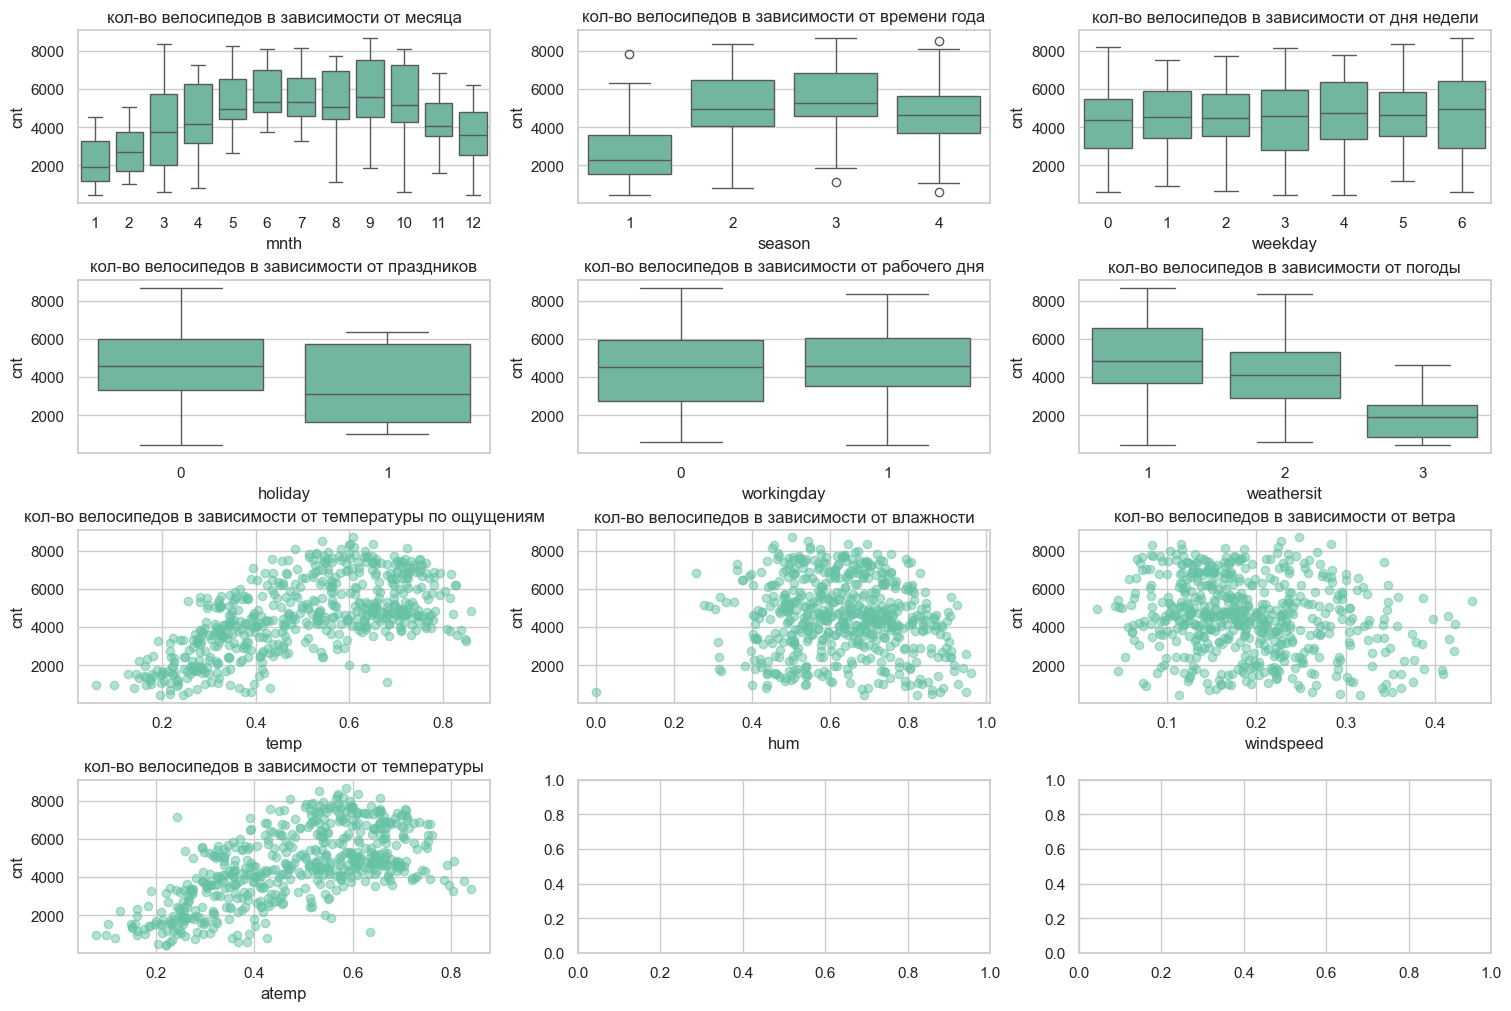

In [746]:
# строим графики завиисмости cnt от всех признаков
fig, axes = plt.subplots(4, 3, figsize=(15, 10), constrained_layout=True)

sns.boxplot(x = "mnth", y = "cnt", data=train, ax = axes[0][0])
axes[0][0].set_title("кол-во велосипедов в зависимости от месяца") 

sns.boxplot(x = "season", y = "cnt", data=train, ax = axes[0][1])  
axes[0][1].set_title("кол-во велосипедов в зависимости от времени года") 

sns.boxplot(x = "weekday", y = "cnt", data=train, ax = axes[0][2])
axes[0][2].set_title("кол-во велосипедов в зависимости от дня недели")

sns.boxplot(x = "holiday", y = "cnt", data=train, ax = axes[1][0])
axes[1][0].set_title("кол-во велосипедов в зависимости от праздников")

sns.boxplot(x = "workingday", y = "cnt", data=train, ax = axes[1][1])
axes[1][1].set_title("кол-во велосипедов в зависимости от рабочего дня")

sns.boxplot(x = "weathersit", y = "cnt", data=train, ax = axes[1][2])
axes[1][2].set_title("кол-во велосипедов в зависимости от погоды")

axes[2][0].scatter(x_train["temp"], y_train, alpha = 0.5,)
axes[2][0].set_title("кол-во велосипедов в зависимости от температуры по ощущениям")
axes[2, 0].set_xlabel("temp")
axes[2, 0].set_ylabel("cnt")

axes[2][1].scatter(x_train["hum"], y_train, alpha = 0.5)
axes[2][1].set_title("кол-во велосипедов в зависимости от влажности")
axes[2, 1].set_xlabel("hum")
axes[2, 1].set_ylabel("cnt")

axes[2][2].scatter(x_train["windspeed"], y_train, alpha = 0.5)
axes[2][2].set_title("кол-во велосипедов в зависимости от ветра")
axes[2, 2].set_xlabel("windspeed")
axes[2, 2].set_ylabel("cnt")

axes[3][0].scatter(x_train["atemp"], y_train, alpha = 0.5)
axes[3][0].set_title("кол-во велосипедов в зависимости от температуры")
axes[3, 0].set_xlabel("atemp")
axes[3, 0].set_ylabel("cnt")


plt.show()

Сделайте выводы по графикам. В частности, ответьте на следующие вопросы.
* Есть ли в данных явные выбросы, то есть точки, далеко находящиеся от основной массы точек?
* Стоит ли рассматривать какие-либо нелинейные функции от признаков? Не стоит придумывать сложные функции, достаточно рассмотреть $x^2, \log x, I\{x > c\}$.
* <font color="red"><b>Не стоит сильно закапываться в анализ графиков и подбор функций.</b></font> Время у всех ограничено, а есть более интересные задачи. Достаточно сделать 2-4 содержательных вывода и рассмотреть возможность добавления небольшого количества признаков.



**Выводы по графикам:**

1) Как видно из графика `кол-во велосипедов в зависимости от влажности` есть 1 точка с сильным выбросом в лвевом нижнем углу. Кроме того на графике с силой ветра, есть точки находящиеся слева от оснвной массы и есть несколько точек в правом нижнем углу на графике с температурой

2) График `кол-во велосипедов в зависимости от температуры/температуры по ощущениям` можно описывать параболой, тогда для их описания будем использовать $x^2$

3) Что сделаем с признаками:

* weathersit, mnth, holiday workingday - категориальные
* temp - квадратичные

4) atemp почти дублирует temp, а season сильно связан с mnth, поэтому чтобы уменьшить мультиколлинеарность, можно убрать atemp и season (оставив temp и mnth).





#### 2. Подготовка данных

Опишите по шагам процедуру предобработки данных, которая будет включать работу с выбросами, преобразования вещественных и категориальных признаков, возможно, создание каких-либо новых признаков (посмотрите <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">пример</a> с занятия). То, как именно выполнять подготовку данных, является целым исскуством. Здесь нет "правильного" подхода, здесь есть метрика качества на тестовом множестве, которая в последствии оценит качество вашей модели.

*Обратите внимание, от того, насколько качественно вы проведете визуальный анализ и подготовку данных, будет зависеть качество ваших моделей на следующих шагах.*

**Процедура предобработки данных:**

**a) Удалим выбросы для числовых параметров, визуально выбрав такие границы, которые отбрасывают точки вне основной массы.

**b) Для категориальных сложнее визуально провести удаление выбросов, поэтому удалим одно макимальное и одно минимальное значение, в котором может лежать наибольшый выброс

**c) Добавим признак $temp^2$

**d) Перекодируем категориальные признаки с помощью OneHotEncoder


Реализуйте данную процедуру.

In [747]:
categorial_features = ["mnth", "weekday", "holiday", "workingday", "weathersit"]
real_features = ["temp", "hum", "windspeed"]
# фильтр по вещественным (на train)
mask = (
    train["temp"].between(0.1, 0.8) &
    train["hum"].between(0.2, 0.96) &
    train["windspeed"].between(0.04, 0.4)
)
train = train.loc[mask].copy()

# удалим по 1 min/max cnt внутри каждой категории
drop_idx = set()
for col in categorial_features:
    drop_idx |= set(train.groupby(col)["cnt"].idxmin())
    drop_idx |= set(train.groupby(col)["cnt"].idxmax())

train_clear = train.drop(index=drop_idx)

len(train_clear)

525

In [748]:
# преобразуем вещественные признаки
train_clear["temp_square"] = train_clear["temp"]**2

test["temp_square"] = test["temp"]**2


if "temp_square" not in real_features:
    real_features.append("temp_square")


In [749]:
# преобразуем категориальные признаки

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

train_cat = encoder.fit_transform(train_clear[categorial_features]) 
test_cat = encoder.transform(test[categorial_features])

Y_train = train_clear["cnt"]
X_train = np.hstack([train_clear[real_features].to_numpy(), train_cat])
X_test  = np.hstack([test[real_features].to_numpy(),  test_cat])

# список категориальных признаков после кодировки
categorial_names = encoder.get_feature_names_out(categorial_features)

columns_names = list(real_features) + list(categorial_names)
X_train_df = pd.DataFrame(X_train, columns=columns_names, index=train_clear.index)
X_test_df = pd.DataFrame(X_test, columns=columns_names, index=test.index)

len(X_train_df)


525

#### 3. Обучение модели и ее анализ


*Помочь в выполнении может ноутбук по линейной регрессии с занятия 2.*

Обучите линейную регрессию из `sklearn` на полученных данных и посмотрите на полученные оценки коэффициентов (в т.ч. свободный коэффициент).

In [750]:
#поиск коэффицентов и обучение модели
model_full = LinearRegression()
model_full.fit(X_train, train_clear["cnt"])

LinearRegression()

<font color="green" size="5"><b>Исправления ниже</b></font>

In [ ]:
#выведем найденные коэффиценты
print("intercept =", model_full.intercept_)
coef = pd.Series(model_full.coef_, index=columns_names)
coef.sort_values(key=lambda s: s.abs(), ascending=False)

temp            22150.908729
temp_square    -15953.816122
hum             -3552.788494
windspeed       -3189.801691
weathersit_3    -1273.330952
mnth_10           896.863191
mnth_9            655.057356
weekday_6         583.168124
mnth_11           558.047891
holiday_1        -492.630496
mnth_12           437.948719
workingday_1      364.314264
mnth_2           -345.354788
mnth_5            320.458377
mnth_7            157.116719
mnth_4           -153.841001
mnth_3            142.318031
weathersit_2     -141.392785
weekday_3        -135.124731
mnth_6            115.371056
weekday_2        -115.191968
weekday_5         105.469512
weekday_4          32.393606
weekday_1         -15.862652
mnth_8              3.704150
dtype: float64

Посчитайте ошибку предсказания на тестовой выборке по метрикам RMSE, MAE, MAPE.  Подробнее можно почитать в <a href="https://thetahat.ru/courses/ad/main/3/1_linreg">ноутбуке</a> с занятия.

*Замечание.* Если в тестовой части тоже есть "большие" выбросы, их стоит убрать. Наша модель не должна пытаться их предсказать (например, сбои в работе сервиса), но в то же время выбросы вносят существенный вклад в значение метрики. Особенно стоит обратить на это внимание в случае высоких значений метрик, например, значения MAPE $\approx$ 100% &mdash; точно плохо.

In [752]:
# посчитаием значения ошибок без обработки выбросов
test_pred = model_full.predict(X_test)

rmse = mean_squared_error(Y_test, test_pred) ** 0.5
print ("RMSE:", rmse)
mae = mean_absolute_error(Y_test, test_pred)
print ("MAE:", mae)
mape = mean_absolute_percentage_error(Y_test, test_pred) * 100
print ("MAPE:", mape, "%")


RMSE: 1373.7688686269707
MAE: 1182.354676481003
MAPE: 121.81634632953988 %


In [753]:
# теперь проведем фильрацию ввыбросов в test
# фильтр только вещественным (на test)
mask = pd.Series(True, index=test.index)
for col in real_features:
    q01 = test[col].quantile(0.025)
    q99 = test[col].quantile(0.975)
    mask &= test[col].between(q01, q99)

test_clear = test.loc[mask].copy()
len(test_clear)


124

In [754]:
# кодировка отфильтрованных значений

test_cat_clear = encoder.transform(test_clear[categorial_features])
X_test_clear  = np.hstack([test_clear[real_features].to_numpy(), test_cat_clear])
Y_test_clear = test_clear["cnt"]

test_pred = model_full.predict(X_test_clear)

# посчитаием значения ошибок c обработкой выбросов
rmse = mean_squared_error(Y_test_clear, test_pred) ** 0.5
print ("RMSE:", rmse)
mae = mean_absolute_error(Y_test_clear, test_pred)
print ("MAE:", mae)
mape = mean_absolute_percentage_error(Y_test_clear, test_pred) * 100
print ("MAPE:", mape, "%")

RMSE: 1306.7070320510788
MAE: 1125.7877615922187
MAPE: 32.478945067144025 %


Попробуйте посчитать оценку коэффициентов с помощью точной аналитической формулы, полученной на занятии (самостоятельно реализуйте ее). Не забудьте про константный признак.

In [755]:
X = X_train
Y = Y_train.to_numpy()

X1 = np.hstack([np.ones((X.shape[0], 1)), X]) # добавим константный признак

beta = (np.linalg.pinv(X1.T @ X1)) @ (X1.T @ Y) # считаем формулу

# выведем полученнные коэффиценты
res = pd.Series(beta, index=["intercept"] + list(columns_names))
res.sort_values(key=lambda s: s.abs(), ascending=False)

temp            22150.908729
temp_square    -15953.816122
hum             -3552.788494
windspeed       -3189.801691
weathersit_3    -1273.330952
mnth_10           896.863191
mnth_9            655.057356
weekday_6         583.168124
mnth_11           558.047891
holiday_1        -492.630496
mnth_12           437.948719
intercept         411.542250
workingday_1      364.314264
mnth_2           -345.354788
mnth_5            320.458377
mnth_7            157.116719
mnth_4           -153.841001
mnth_3            142.318031
weathersit_2     -141.392785
weekday_3        -135.124731
mnth_6            115.371056
weekday_2        -115.191968
weekday_5         105.469512
weekday_4          32.393606
weekday_1         -15.862652
mnth_8              3.704150
dtype: float64

Посчитайте также определить матрицы $X^T X$

In [756]:
det = np.linalg.det(X1.T @ X1)
print("det =", det)

det = -2.6603628300165495e+21


Наблюдается ли какая-то проблема?

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
Подумайте о зависимостях между признаками. Есть ли среди них сильно зависимые признаки? 
    
Причем, возможно, вы уже могли решить эту проблему на предыдущих этапах. Тогда все хорошо :)
</details>

Если выше была проблема, исправьте ее проблему, посчитайте оценки коэффициентов, а также ошибку предсказания.

Сделайте выводы.

**Выводы:**

Мы провели расчет коэффицеетов линейной регрессии двумя способами (градиентный спуск и матрицная формула) и получили в точности одинаковые коэффиценты. В тетсовых данных мы проводили очистку выбросов с помощью квантилей только по вещественным признаккам, так как именно у них получиоись самые большие коэфииценты влияния на модель. 
Самые большие коэффиценты получились у признаков temp, temp_square. То есть температура, грубо говоря, температура имеет наибольшее значение.

После очистики данных ошибка MAPE снизмилась с 120 до 30 процентов, что говорит о том что, наша модель плохо работает с выбросами и хорошо с отфильтрованными значениями.

det($X^T X$) получился не ноль ⇒ матрица обратима, значит проблем с заивисимостью признаков друг от друга нет

*Замечание.* Не расстраивайтесь, если у вас получится не очень хорошее качество, это нормально. Вы провели только небольшую предобработку данных и обучили *простую* модель. Более сложные методы обработки данных и обучения ждут вас впереди. Главное &mdash; с чего-то начать!

<img src="https://thetahat.ru/files/ad/main/3/bike2.png">

*Ты молодец, уже две задачи позади!* 🎉 

*Впереди еще лве задачи, но не пугайся, они тебе понравятся! А пока сделай перерыв, возьми чай или кофе* 😊

---
### Задача 3.

*Теперь давайте углубимся в теорию градиентных методов оптимизации. Эти подходы будут часто встречаться, поэтому важно освоить их применение. Для этого применим градиентные методы в другом методе обучения линейной регрессии.*

В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Рассмотрим линейную регрессию $y(x) = x^T \theta$, причем для оценки $\theta$ будем рассматривать функцию потерь Хьюбера
$$R(x) = \frac{x^2}{2} I\{|x| \leqslant c\} + c\left(|x| - \frac{c}{2}\right)I\{|x| > c\}.$$

Тем самым задача оптимизации имеет вид
$$\sum_{i=1}^n R(Y_i - x_i^T \theta) \longrightarrow \min_{\theta \in \mathbb{R}^d}.$$

Нарисуйте график $R(x)$

Text(0, 0.5, 'R(x)')

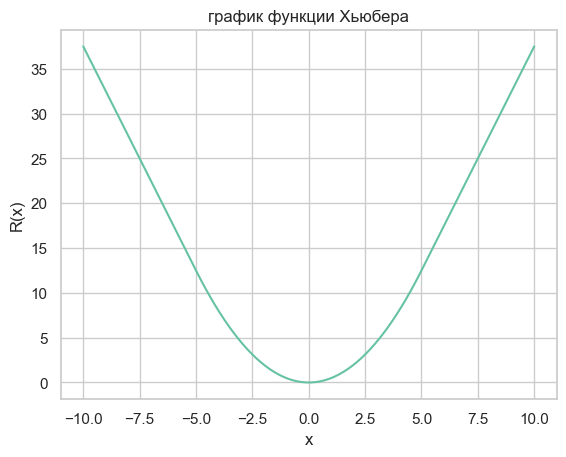

In [800]:
plt.figure()
x = np.linspace(-10, 10, 100)
c = 5
r = (x**2/2)*(np.abs(x) <= c) + c*(np.abs(x) - c/2)*(np.abs(x) > c)
plt.plot(x, r)
plt.title("график функции Хьюбера")
plt.xlabel("x")
plt.ylabel("R(x)")

В чем польза выбора такой функции потерь?

<br/><details>
<summary> ➡️ Кликни для показа подсказки </summary>
    
1. Подумайте, что происходит в случае больших отклонений предсказаний от истины? Что это за точки?
    
2. Обратите внимание на поведение $R(x)$ в точке $x=c$.
</details>

При небольших ошибках < С, функция потерь квадратиная (МНК). При больших абсолютных отклонениях функция станивится линейной. Таким образом,  содной стороны более усточива к выбросам и дает на на них не такое больше отклонение, а с другой стороны на большой части данных (не выбросы) она дает правильную оценку с помощью МНК

Выпишите математические формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

<font color="green" size="5"><b>Исправления ниже</b></font>

GD: Рассмотрим 2 множества индексов для конкретного $\theta_t$:

$I_t=\{i\in\{1,\dots,n\}:\ |Y_i-x_i^T\theta_t|\le c\},\qquad J_t=\{i\in\{1,\dots,n\}:\ |Y_i-x_i^T\theta_t|>c\}.$

Тогда градиент целевой функции $F(\theta)=\sum_{i=1}^n R(Y_i-x_i^T\theta)$ в точке $\theta_t$ имеет вид

$$\nabla_{\theta}F(\theta_t)=\sum_{i\in I_t} x_i(x_i^T\theta_t-Y_i)+c\sum_{i\in J_t} x_i\,\operatorname{sign}(x_i^T\theta_t-Y_i).$$

Формула градиентного спуска:

$$\theta_{t+1}=\theta_t-\eta\,\nabla_{\theta}F(\theta_t).$$

То есть

$$\theta_{t+1}=\theta_t-\eta\left(\sum_{i\in I_t} x_i(x_i^T\theta_t-Y_i)+c\sum_{i\in J_t} x_i\,\operatorname{sign}(x_i^T\theta_t-Y_i)\right).$$

SGD: на шаге $t$ выбираем батч индексов $B_t=\{i_1^{(t)},\dots,i_b^{(t)}\}\subset\{1,\dots,n\}$.

Тогда стохастический градиент можно записать так:

$$g_t=\frac{1}{b}\left(\sum_{i\in B_t:\ |Y_i-x_i^T\theta_t|\le c} x_i(x_i^T\theta_t-Y_i)+c\sum_{i\in B_t:\ |Y_i-x_i^T\theta_t|>c} x_i\,\operatorname{sign}(x_i^T\theta_t-Y_i)\right),$$

а обновление имеет вид

$\theta_{t+1}=\theta_t-\eta\,g_t.$


<font color="green" size="5"><b>Исправления выше</b></font>

*Хочется что-то закодить? Поехали!*

**2.** Реализуем теперь класс. **При реализации класса запрещено пользоваться ИИ-инструментами.**

In [814]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000) -> None:
        """Инициализирует модель.

        Параметры: c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак. max_iter
        (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.
        """
        X = np.asarray(X)
        y = np.asarray(y)
        # d = число признаков
        d = X.shape[1]
        if self.fit_intercept:
            theta = np.zeros(d + 1) # theta = [b, w1, ..., wd]
        else:
            theta = np.zeros(d) # theta = [w1, ..., wd]

        theta_next = theta.copy()
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")

        X_work = X.copy()
        if self.fit_intercept:
            X_work = np.c_[np.ones(X.shape[0]), X_work]

        
        lr = 0.01 # шаг обучения (learning rate)
        tol = 1e-4 # критерий остановки по изменению theta
        self.n_iter_ = 0


        # на каждой итерации считаем градиент по всем объектам и делаем один шаг обновления.
        for _ in range(self.max_iter):
            theta = theta_next.copy()


            # где r_i — остаток (ошибка предсказания).
            grad = np.zeros_like(theta)

            for i in range(X_work.shape[0]):

                r_i = X_work[i] @ theta - y[i]

                if (abs(r_i) <= self.c):
                    grad += X_work[i] * r_i
                else:
                    grad += X_work[i] * self.c * np.sign(r_i)

            theta_next = theta - lr * grad

            step = np.linalg.norm(theta_next - theta)
            if step < tol:
                break
            self.n_iter_ += 1
        
        # Сохраняем параметры в стиле sklearn: отдельно coef_ и intercept_.
        if self.fit_intercept:
            self.intercept_ = theta_next[0]
            self.coef_ = theta_next[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = theta_next
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """
        X_copy = X.copy()
        if X_copy.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        pred = X @ self.coef_ + self.intercept_
        return pred

**3.** Загрузите данные из файлов `train.csv`, `test.csv`. Не забудьте, что всю аналитику, а также процесс обучения и подбор гиперпараметров необходимо выполнять на обучающей выборке.

In [767]:
train_2 = pd.read_csv("train.csv")
test_2 = pd.read_csv("test.csv")

train_2.head()

,feature_1,feature_2,feature_3,target
0,2.320800,-1.098571,0.117091,162.910894
1,0.625119,-0.782367,-0.813596,21.113006
2,-0.807648,-0.185054,-1.446535,-36.128990
3,-0.291837,-1.616474,-0.761492,-56.474495
4,0.938747,0.087531,0.607112,189.589573


Посмотрите на зависимость целевой переменной от каждого признака.

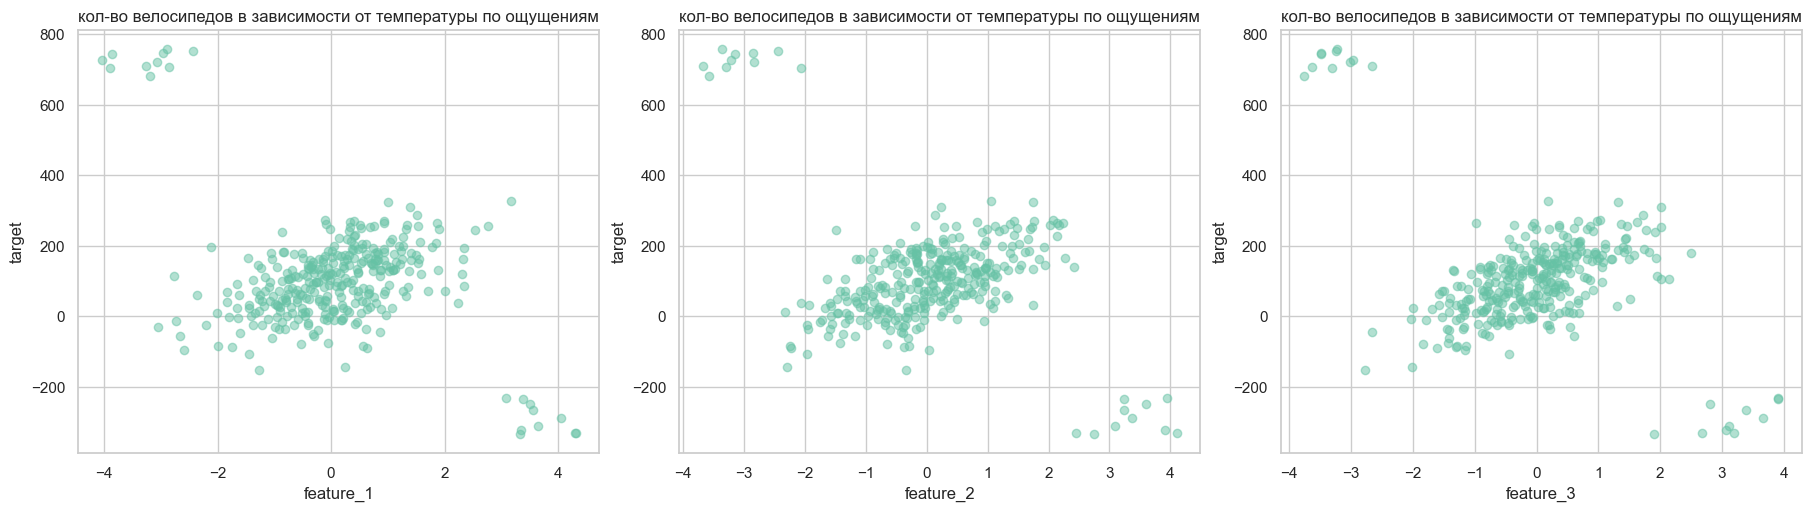

In [798]:
# строим графики завиисмости cnt от всех признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
features_col_2 = ["feature_1", "feature_2", "feature_3"]
for i in range (0, 3):
    axes[i].scatter(train_2[features_col_2[i]], train_2["target"], alpha = 0.5)
    axes[i].set_title("кол-во велосипедов в зависимости от температуры по ощущениям")
    axes[i].set_xlabel(features_col_2[i])
    axes[i].set_ylabel("target")


plt.show()

Что можно сказать о наличии возможных выбросов? Какое влияние они могут оказать? 

<font color="green" size="5"><b>Исправления ниже</b></font>

На графиках видно наличие возможных выбросов, причём не только отдельных точек, а целых групп. Хорошо выделяются две группы: точки в левом верхнем углу (примерно при $x\approx -3.5$ и $y\approx 700$) и точки в правом нижнем углу (примерно при $x\approx 3$-$4$ и $y\approx -300$). Они заметно отклоняются от основной линейной зависимости и могут сильно перетягивать на себя обычную линейную регрессию, смещая коэффициенты и увеличивая ошибку. Поэтому здесь разумно использовать устойчивую к выбросам модель, например регрессию Хьюбера.

<font color="green" size="5"><b>Исправления выше</b></font>

**4.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике [MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

In [ ]:
# обучаем обычную линейную регрессию
model = LinearRegression()
model.fit(train_2[features_col_2], train_2["target"])


test_predict_2 = model.predict(test_2[features_col_2])
rmse = mean_squared_error(test_predict_2, test_2["target"]) ** 0.5
print ("rmse =", rmse)


rmse = 130.48297440711926


Что можно сказать о качестве нашей модели?

Видно, что RMSE получилось очень большим без выброса крайних точек, в силу МНК точки сильно удаленные от основной массы перетягивают коэффиценты на себя. Например, если строить отфильтрованные значения то видно что точность модели сильно повышается

**5.** Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [ ]:
# обучение модели Хьюбера
model_huber = HuberRegression()
model_huber.fit(train_2[features_col_2], train_2["target"])

test_predict_huber = model_huber.predict(test_2[features_col_2])
rmse_huber = mean_squared_error(test_predict_huber, test_2["target"]) ** 0.5
print ("rmse_huber =", rmse_huber)

rmse_huber = 4.774362272677365


Модель Хьюбера оказалась сильно точнее так как она не так сильно чусвтивтально к точкам в далеке от основной массы и может их "игнорироват" при построении модели

**6.** Для обучающей выборки постройте два графика (по графику на каждую модель), на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

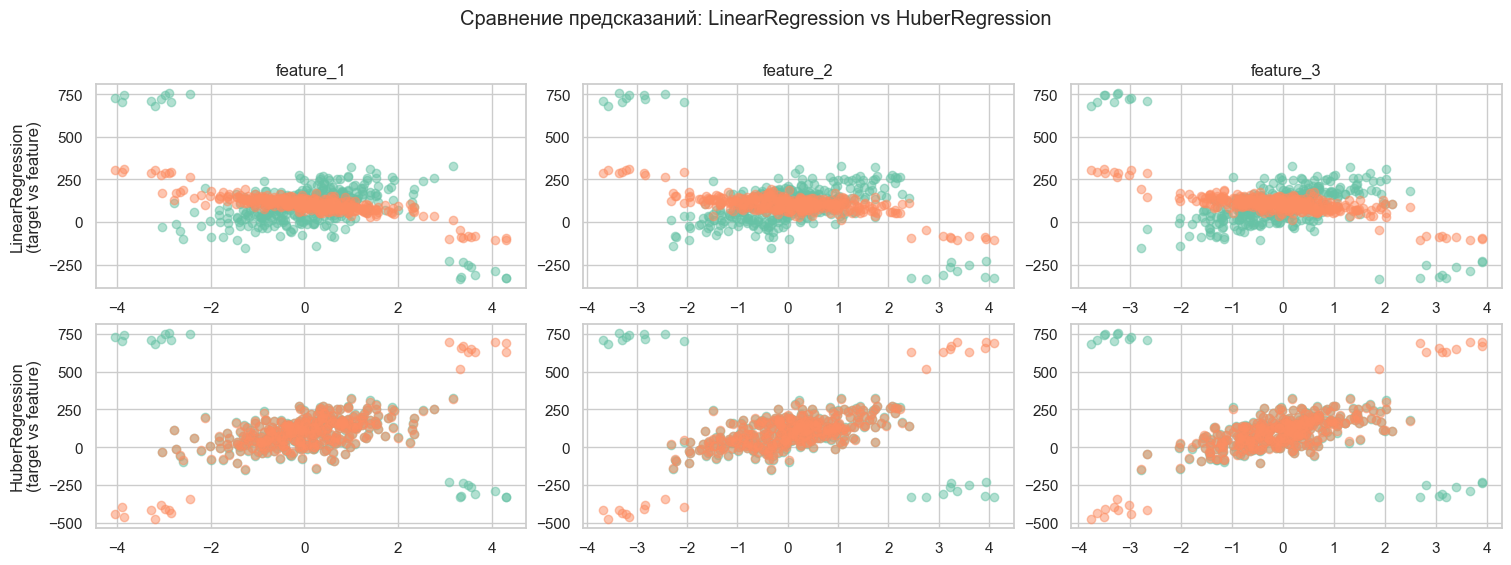

In [793]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5), constrained_layout=True)

# названия столбцов (признаки)
for i, feat in enumerate(features_col_2):
    axes[0, i].set_title(feat)

# подписи строк (модели)
axes[0, 0].set_ylabel("LinearRegression\n(target vs feature)")
axes[1, 0].set_ylabel("HuberRegression\n(target vs feature)")

# общий заголовок
fig.suptitle("Сравнение предсказаний: LinearRegression vs HuberRegression", y=1.1)
for i in range (0, 3):
    axes[0][i].scatter(train_2[features_col_2[i]], train_2["target"], alpha = 0.5)
    axes[0][i].scatter(train_2[features_col_2[i]], model.predict(train_2[features_col_2]) , alpha = 0.5)

for i in range (0, 3):
    axes[1][i].scatter(train_2[features_col_2[i]], train_2["target"], alpha = 0.5)
    axes[1][i].scatter(train_2[features_col_2[i]], model_huber.predict(train_2[features_col_2]) , alpha = 0.5)

Что можно заметить на этих графиках?

Видно, что Huber меньше “тянется” к одиночным выбросам: он лучше описывает основную массу точек, потому что большие ошибки у него штрафуются линейно. У обычной линейной регрессии выбросы могут сильно менять наклон и из-за этого предсказания для большинства точек становятся хуже.

**7.** Обучите регрессию Хьюбера на данных из задачи 2 и сравните качество модели с простой линейной регрессией, которую вы построили в задаче 2.

In [811]:
# обучение новой модели
model_full_huber = HuberRegression()
model_full_huber.fit(X_train, train_clear["cnt"])
# gjlcxtn rfxtcndf
test_predict_huber_2 = model_full_huber.predict(X_test_clear)
rmse_huber_2 = mean_squared_error(Y_test_clear, test_predict_huber_2) ** 0.5
print ("RMSE_huber:", np.round(rmse_huber_2, 1))
mae_huber_2 = mean_absolute_error(Y_test_clear, test_predict_huber_2)
print ("MAE_huber:", np.round(mae_huber_2, 1))
mape_huber_2 = mean_absolute_percentage_error(Y_test_clear, test_predict_huber_2) * 100
print ("MAPE_huber:", np.round(mape_huber_2, 1))


RMSE_huber: 1740.1
MAE_huber: 1447.0
MAPE_huber: 43.3


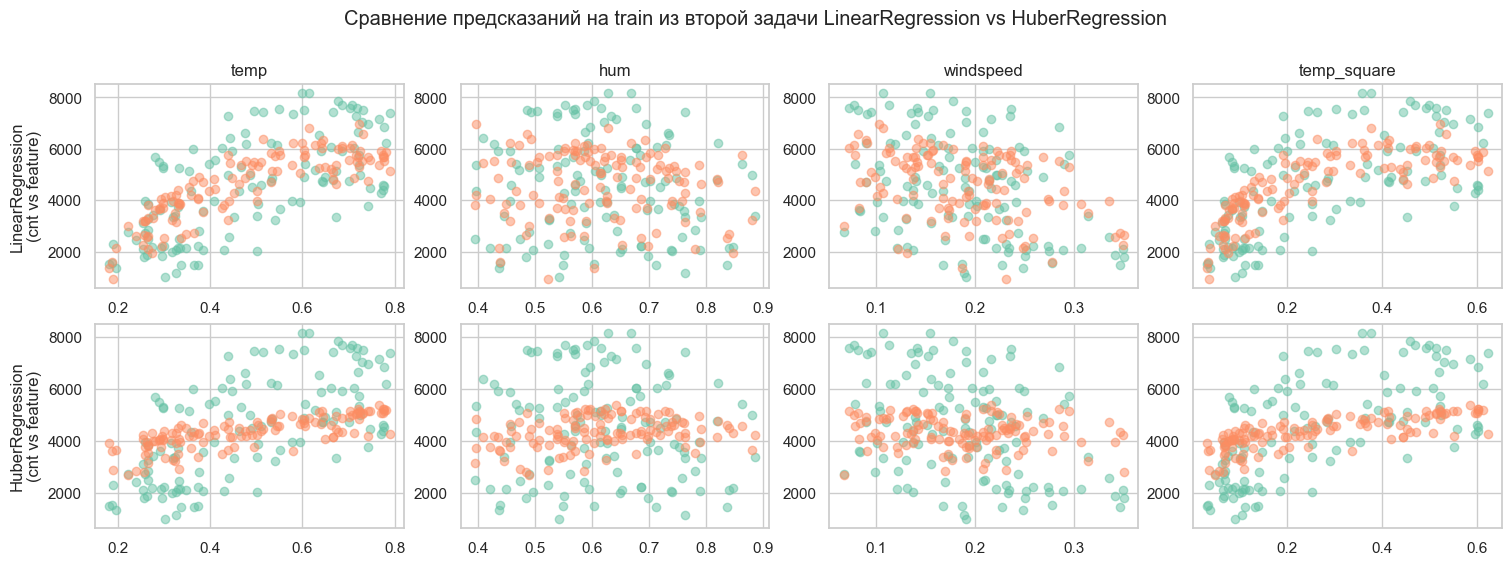

In [804]:
# также построим графики для каждой модели, на которых изображена зависимость таргета от каждого из вещественнных признаков
fig, axes = plt.subplots(2, 4, figsize=(15, 5), constrained_layout=True)

# названия столбцов (признаки)
for i, feat in enumerate(real_features):
    axes[0, i].set_title(feat)

# подписи строк (модели)
axes[0, 0].set_ylabel("LinearRegression\n(cnt vs feature)")
axes[1, 0].set_ylabel("HuberRegression\n(cnt vs feature)")

fig.suptitle("Сравнение предсказаний на train из второй задачи LinearRegression vs HuberRegression", y=1.1)

for i in range (0, 4):
    axes[0][i].scatter(test_clear[real_features[i]], test_clear["cnt"], alpha = 0.5)
    axes[0][i].scatter(test_clear[real_features[i]], model_full.predict(X_test_clear) , alpha = 0.5)

for i in range (0, 4):
    axes[1][i].scatter(test_clear[real_features[i]], test_clear["cnt"], alpha = 0.5)
    axes[1][i].scatter(test_clear[real_features[i]], model_full_huber.predict(X_test_clear) , alpha = 0.5)

**Вывод:**

На этих данных линейная регрессия на test получилась чуть лучше по метрикам (MAPE меньше), а на графиках test лин. рег показывает боольшое свопадение с реальными данными. Скорее всего это потому, что после фильтрации выбросов данные стали “спокойными”, и модель Хьюбера уже не даёт преимущества. При этом на сырых данных с выбросами Huber обычно полезнее, потому что не так сильно уезжает из-за крайних точек.

---
### Задача 4.

*Наконец, давайте исследуем еще один метод обучения линейных моделей. Эта задача теоретическая, кодить ничего не требуется. Мы рассмотрим только случай простой модели, потому как в более сложном случае решение существенно усложняется.*


Рассмотрим модель одномерной регрессии $y(x) = \theta x$, где $x \in \mathbb{R}$ &mdash; одномерный признак, $y \in \mathbb{R}$ &mdash; целевой признак, $\theta \in \mathbb{R}$ &mdash; неизвестный параметр. Имеется выборка размера $n$, полученная по правилу
	$$Y_i = \theta x_i + \varepsilon_i,\ \ \ i=1,...,n,$$
где $\varepsilon_i$ &mdash; случайная ошибка измерений.

Оценку параметра $\theta$ будем искать методом наименьших модулей, то есть $$\sum_{i=1}^n \left|Y_i - \theta x_i\right| \to \min_\theta.$$

Какие преимущества и недостатки такой модели по сравнению с методом наименьших квадратов?

Приимущества:
1) Модель более устойчива к выбросам: большое отклонение учитывается линейно (через
$|r∣$), а не квадратично, поэтому отдельные “плохие” точки не так сильно портят оценку, как в МНК.
2) В этом одномерном случае оценку можно найти довольно быстро и точно

Недостатки:
1) Возможна неединственность ответа: у функции суммы модулей могут быть “плоские” участки, и тогда любой $\Theta$ из некоторого интервала даёт один и тот же минимум (интуитивно — как в примере, где между вариантами нет разницы по сумме модулей). В МНК минимум обычно единтсвенный
2) Потеря негладкая (модуль), поэтому в общем случае (особенно в многомерной регрессии) оптимизация обычно сложнее, чем для МНК, где есть простое аналитическое решение.

Предложите точный алгоритм поиска оценки параметра $\theta$, работающий за время $O(n \log n)$. Приведите его описание и теоретическое обоснование.

Рассмотрим графическое решение этой задачи.

Для начала будем считать, что все $x_i \ge 0$ и $y_i \ge 0$; далее обобщим рассуждения на общий случай.

Заметим, что наша задача — выбрать такой коэффициент наклона прямой, выходящей из нуля, чтобы суммарное расстояние по оси $y$ до всех точек было минимально. Обозначим
$$
L(\theta)=\sum_{i=1}^n \lvert Y_i-\theta x_i\rvert.
$$

## 1) Почему оптимум достигается в “переломах”
Функция $L(\theta)$ является кусочно-линейной, так как это сумма кусочно-линейных функций $\lvert Y_i-\theta x_i\rvert$. Следовательно, минимум такой функции достигается либо:
- в точке перелома, либо
- на отрезке между переломами, где наклон равен нулю.

Переломы происходят в тех $\theta$, где для некоторого $i$ выполняется
$$
Y_i-\theta x_i = 0 \quad \Longleftrightarrow \quad \theta=\frac{Y_i}{x_i}\quad (x_i\ne 0).
$$
Геометрически это означает: прямая $y=\theta x$, выходящая из начала координат, проходит через точку $(x_i,Y_i)$. Значит, кандидатами на ответ являются $\theta$ вида $\frac{Y_i}{x_i}$ (возможны совпадения, если несколько точек лежат на одной прямой через начало).

## 2) Алгоритм (для $x_i\ge 0,\,y_i\ge 0$)
**Шаг 1.** Отсортируем все точки по возрастанию угла наклона прямой из начала координат в точку, то есть по величине
$$
\frac{Y_i}{x_i}.
$$
(Пока все точки в первой четверти, это значения от $0$ до $+\infty$.) Сортировка занимает $O(n\log n)$.

**Шаг 2.** Будем по очереди рассматривать переломы $\theta_1\le \theta_2\le \dots \le \theta_n$, где $\theta_k=\frac{Y_{i_k}}{x_{i_k}}$. Для первой точки посчитаем значение
$$
L(\theta_1)=\sum_{i=1}^n \lvert Y_i-\theta_1 x_i\rvert
$$
“в лоб” за $O(n)$.

## 3) Как обновлять $L(\theta)$ за $O(1)$ при переходе к следующему перелому
На любом промежутке между соседними переломами знаки выражений $(Y_i-\theta x_i)$ фиксированы, значит $L(\theta)$ там линейна. Производная (наклон) на таком промежутке равна
$$
\frac{d}{d\theta}L(\theta)=\sum_{i\in B} x_i-\sum_{i\in A} x_i,
$$
где $A$ — индексы точек, для которых $Y_i-\theta x_i>0$, а $B$ — индексы, для которых $Y_i-\theta x_i<0$.

Когда мы переходим через перелом $\theta=\frac{Y_k}{x_k}$, ровно одно слагаемое меняет знак, поэтому наклон меняется на $2x_k$. Значит:
- наклон на следующем промежутке можно обновить за $O(1)$;
- так как между переломами $L(\theta)$ — линейная функция, то значение $L(\theta_{k+1})$ можно пересчитать из $L(\theta_k)$ за $O(1)$, зная текущий наклон и разность $\theta_{k+1}-\theta_k$.

## 4) Где находится минимум
После сортировки можно одним проходом идти слева направо по всем переломам $\theta_1,\dots,\theta_n$, поддерживая:
- текущее значение $L(\theta_k)$;
- текущий наклон на промежутке.

Минимум будет:
- либо в точке $\theta_k$, где наклон меняет знак “с минуса на плюс”;
- либо на отрезке между $\theta_k$ и $\theta_{k+1}$, если на нём наклон равен нулю (тогда любой $\theta$ на этом отрезке оптимален).

Итого: сортировка $O(n\log n)$, один проход $O(n)$, общая сложность $O(n\log n)$.

## Обобщение на общий случай ($x_i$ и $y_i$ произвольные)
- Если $x_i=0$, то вклад равен $\lvert Y_i\rvert$ и не зависит от $\theta$; такие точки не влияют на выбор оптимального $\theta$ (их можно учитывать как константу в $L(\theta)$).
- Если $x_i\ne 0$, переломы всё так же происходят при $\theta=\frac{Y_i}{x_i}$, и сортировка по $\frac{Y_i}{x_i}$ остаётся корректной.
- В формулах выше вместо $x_i$ в “весах” фактически работает $\lvert x_i\rvert$, потому что
$$
\lvert Y_i-\theta x_i\rvert=\lvert x_i\rvert\cdot \left\lvert \theta-\frac{Y_i}{x_i}\right\rvert.
$$
Поэтому рассуждения про кусочно-линейность, переломы и обновление наклона остаются такими же.

Итого, тот же самый алгоритм (с сортировкой по $\frac{Y_i}{x_i}$ для $x_i\ne 0$ и игнорированием точек с $x_i=0$ как констант) работает за $O(n\log n)$ и в общем случае.

*Надеемся, что ты все успел, и тебе понравилось! Ждем тебя на следующей лекции!*

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД